In [1]:
import pandas as pd

In [2]:
d=pd.read_csv("Bank_Churn.csv")
d

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [4]:
dn=d.select_dtypes("int64")
dn

,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,619,42,2,1,1,1,1
1,15647311,608,41,1,1,0,1,0
2,15619304,502,42,8,3,1,0,1
3,15701354,699,39,1,2,0,0,0
4,15737888,850,43,2,1,1,1,0
...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,2,1,0,0
9996,15569892,516,35,10,1,1,1,0
9997,15584532,709,36,7,1,0,1,1
9998,15682355,772,42,3,2,1,0,1


In [5]:
d.columns[d.isna().any()]

Index([], dtype='object')

In [6]:
dn.corr()

,CustomerId,CreditScore,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited
CustomerId,1.000000,0.005308,0.009497,-0.014883,0.016972,-0.014025,0.001665,-0.006248
CreditScore,0.005308,1.000000,-0.003965,0.000842,0.012238,-0.005458,0.025651,-0.027094
Age,0.009497,-0.003965,1.000000,-0.009997,-0.030680,-0.011721,0.085472,0.285323
Tenure,-0.014883,0.000842,-0.009997,1.000000,0.013444,0.022583,-0.028362,-0.014001
NumOfProducts,0.016972,0.012238,-0.030680,0.013444,1.000000,0.003183,0.009612,-0.047820
HasCrCard,-0.014025,-0.005458,-0.011721,0.022583,0.003183,1.000000,-0.011866,-0.007138
IsActiveMember,0.001665,0.025651,0.085472,-0.028362,0.009612,-0.011866,1.000000,-0.156128
Exited,-0.006248,-0.027094,0.285323,-0.014001,-0.047820,-0.007138,-0.156128,1.000000


In [7]:
x=dn[["CustomerId"]]
y=dn["Age"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model= LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_pred=model.predict(x_test)
y_pred

array([38.89034191, 39.00583966, 38.97027585, ..., 39.02851151,
       38.89405168, 38.80660948], shape=(2000,))

In [13]:
y_test

6252    32
4684    43
1731    44
4742    59
4521    27
        ..
6412    53
8285    25
7853    47
1095    29
6929    39
Name: Age, Length: 2000, dtype: int64

In [14]:
from sklearn.metrics import r2_score

In [15]:
r2_score(y_test,y_pred)

-0.000936934309723414

In [16]:
import matplotlib.pyplot as plt

In [19]:
from mpl_toolkits.mplot3d import Axes3D

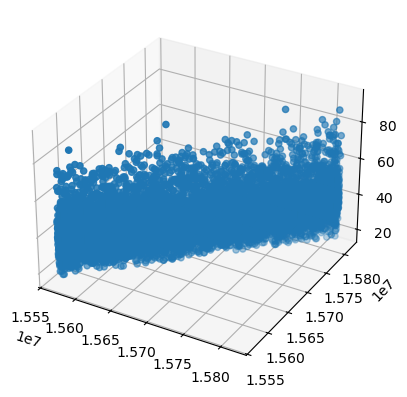

In [22]:
fig = plt.figure()
a = fig.add_subplot(111,projection="3d")
a.scatter(x["CustomerId"],x["CustomerId"],y)
#plt.xlabel(["unit_cost",""])
#plt.ylabel("math score")
plt.show()